In [33]:
def cox_de_boor(t, k, i, knots):
    """
    t: 定义域
    k: 阶数
    i: 基函数的索引
    knots: 节点向量(一个关于时间的非递减序列，用于划分参数区间，决定基函数的分布和曲线的连续性)
    """
    if k == 0:
        return 1.0 if knots[i] <= t < knots[i + 1] else 0.0
    left_bound =0.0
    right_bound =0.0
    if knots[i + k] != knots[i]:
        left_bound = (t - knots[i]) / (knots[i + k] - knots[i]) * cox_de_boor(t, k - 1, i, knots)
    if knots[i + k + 1] != knots[i + 1]:
        right_bound = (knots[i + k + 1] - t) / (knots[i + k + 1] - knots[i + 1]) * cox_de_boor(t, k-1, i + 1, knots)
    return left_bound + right_bound


7


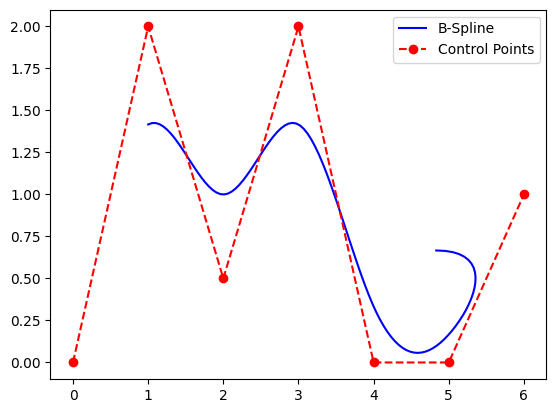

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def basis_function(i, p, u, knots):
    """递归计算基函数值"""
    if p == 0:
        return 1.0 if knots[i] <= u < knots[i+1] else 0.0
    else:
        denom1 = knots[i+p] - knots[i]
        term1 = (u - knots[i])/denom1 * basis_function(i, p-1, u, knots) if denom1 !=0 else 0
        denom2 = knots[i+p+1] - knots[i+1]
        term2 = (knots[i+p+1] - u)/denom2 * basis_function(i+1, p-1, u, knots) if denom2 !=0 else 0
        return term1 + term2

# 参数定义
ctrl_pts =np.array([[0, 0], [1, 2], [2, 0.5], [3, 2], [4, 0], [5, 0], [6, 1]]) #np.array([[0,0], [1,4], [3,2], [5,5], [7,0]])
degree = 3  # 三次样条
knots = np.arange(len(ctrl_pts) + degree + 2) #[0,0,0,0, 0.3, 0.7, 1,1,1,1]  # 非均匀节点向量

# 生成曲线点
u_values = np.linspace(knots[degree], knots[-degree - 1], 100) #np.linspace(0, 1, 100)
curve_pts = []
for u in u_values:
    pt = np.zeros(2)
    for i in range(len(ctrl_pts)):
        N = basis_function(i, degree, u, knots)
        pt += ctrl_pts[i] * N
    curve_pts.append(pt)
curve_pts = np.array(curve_pts)

# 绘图
plt.plot(curve_pts[:,0], curve_pts[:,1], 'b-', label='B-Spline')
plt.plot(ctrl_pts[:,0], ctrl_pts[:,1], 'ro--', label='Control Points')
plt.legend()
plt.show()